
# QA2 — Knowledge preservation and RDF–text faithfulness (QA2.1/QA2.2-aligned)

This notebook implements the QA2 metrics described in the thesis tables. QA2.1 compares each aligned English–target RDF-to-text instance through verbalisation similarity, complete triple-set similarity, predicate diagnostics, and source-to-target numeric/date preservation. QA2.2 evaluates target RDF–text coverage, text groundedness, target triple-to-text literal retention, and relative literal retention using exact-size English gold calibration.

All reportable semantic metrics are calculated with L2-normalised multilingual sentence embeddings through the shared `audit_metric_core.py`. English RDF is always read from `modifiedtripleset/mtriple`.


In [1]:

from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import hashlib
import importlib.util
import json
import os
import sys
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)


def find_repo_root() -> Path:
    override = Path("/home/vramon/notebooks/WebNLG_MT_eval")
    if override:
        root = Path(override).expanduser().resolve()
        if not (root / "WebNLG_CA_BT").exists():
            raise FileNotFoundError(
                f"WebNLG_CA_BT was not found under {root}"
            )
        return root

    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "WebNLG_CA_BT").exists():
            return candidate.resolve()

    mounted = Path("/mnt/data/RDF-to-text-MT-Evaluation-main")
    if mounted.exists():
        return mounted.resolve()

    raise FileNotFoundError(
        "Repository root not found. Set WEBNLG_REPO_ROOT."
    )


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "WebNLG_CA_BT"
CORE_PATH = (
    REPO_ROOT
    / "audit"
    / "QA_evaluation"
    / "audit_notebooks"
    / "aligned"
    / "audit_metric_core.py"
)
if not CORE_PATH.exists():
    raise FileNotFoundError(
        f"Shared metric core not found: {CORE_PATH}\n"
        "Copy audit_metric_core.py from the supplied package into "
        "audit/QA_evaluation/audit_notebooks/aligned/."
    )

spec = importlib.util.spec_from_file_location(
    "audit_metric_core",
    CORE_PATH,
)
core = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = core
spec.loader.exec_module(core)

if core.CORE_COMPATIBILITY != "audit-text-aligned-2.7":
    raise RuntimeError(
        "QA2 requires audit_metric_core.py compatibility "
        "'audit-text-aligned-2.7', but found "
        f"{core.CORE_COMPATIBILITY!r}."
    )

# Fail before corpus processing if either QA2 sub-question drifts from
# its corresponding table.
core.assert_semantic_cosine_range_contract()
core.assert_qa21_metric_contract()
core.assert_qa22_metric_contract()

CORE_SHA256 = hashlib.sha256(
    CORE_PATH.read_bytes()
).hexdigest()

print("Repository root:", REPO_ROOT)
print("Metric core:", CORE_PATH)
print("Metric compatibility:", core.CORE_COMPATIBILITY)
print("Metric core SHA-256:", CORE_SHA256)

RESULTS_NAME = os.getenv(
    "QA2_RESULTS_NAME",
    "QA2_stress_aligned",
)
RESULTS_DIR = (
    REPO_ROOT
    / "QA_evaluation"
    / "results"
    / RESULTS_NAME
)
CACHE_DIR = (
    REPO_ROOT
    / "QA_evaluation"
    / "cache"
    / "QA2_stress_aligned"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Table QA2.1 defines cosine similarity over L2-normalised multilingual
# sentence embeddings. Non-embedding smoke-test backends are therefore not
# accepted for reportable runs.
SEMANTIC_BACKEND = os.getenv(
    "QA2_SEMANTIC_BACKEND",
    "sentence_transformer",
)
if SEMANTIC_BACKEND != "sentence_transformer":
    raise ValueError(
        "QA2.1 reportable runs require QA2_SEMANTIC_BACKEND="
        "'sentence_transformer'."
    )
SEMANTIC_MODEL = os.getenv(
    "QA2_MODEL_NAME",
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2",
)
BATCH_SIZE = int(os.getenv("QA2_BATCH_SIZE", "128"))
BOOTSTRAP_REPLICATES = int(
    os.getenv("QA2_BOOTSTRAP_REPLICATES", "1000")
)
MAX_ROWS_PER_LANGUAGE = (
    int(os.getenv("QA2_MAX_ROWS"))
    if os.getenv("QA2_MAX_ROWS")
    else None
)
ENGLISH_SUPPORT_PERCENTILE = 5.0
RANDOM_SEED = 42

print("Results directory:", RESULTS_DIR)
print("Semantic backend:", SEMANTIC_BACKEND)
print("Semantic model:", SEMANTIC_MODEL)
print(
    "Rows per language:",
    MAX_ROWS_PER_LANGUAGE or "all",
)


Repository root: /home/vramon/notebooks/WebNLG_MT_eval
Metric core: /home/vramon/notebooks/WebNLG_MT_eval/audit/QA_evaluation/audit_notebooks/aligned/audit_metric_core.py
Metric compatibility: audit-text-aligned-2.7
Metric core SHA-256: d41a631b7be3fba492dfd90317ca7a96d9a24ed93dd52478b7243ed36746004c
Results directory: /home/vramon/notebooks/WebNLG_MT_eval/QA_evaluation/results/QA2_stress_aligned
Semantic backend: sentence_transformer
Semantic model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Rows per language: all


## 1. Parse aligned source and target records

In [2]:

TARGET_LANGUAGES = {
    "es": {
        "label": "Spanish",
        "triple_set": "spanishtripleset",
        "triple_tag": "striple",
    },
    "ca": {
        "label": "Catalan",
        "triple_set": "catalantripleset",
        "triple_tag": "ctriple",
    },
}


def list_corpus_xml_files(root: Path):
    usable, ignored = [], []
    for path in root.rglob("*.xml"):
        relative = path.relative_to(root)
        if (
            any(part.startswith(".") for part in relative.parts)
            or path.name.endswith("-checkpoint.xml")
        ):
            ignored.append(path)
        else:
            usable.append(path)
    return sorted(usable), sorted(ignored)


def node_texts(entry, xpath: str):
    return [
        (node.text or "").strip()
        for node in entry.findall(xpath)
    ]


def lexicalisation_pairs(entry):
    result = defaultdict(list)
    for node in entry.findall("lex"):
        language = (node.get("lang") or "").strip()
        lid = (node.get("lid") or "").strip()
        text = (node.text or "").strip()
        if language:
            result[language].append((lid, text))
    return result


def build_clean_manifest(data_root: Path):
    rows = []
    mapping_rows = []
    entry_rows = []
    parse_errors = []
    xml_files, ignored_files = list_corpus_xml_files(data_root)

    for xml_path in xml_files:
        relative = xml_path.relative_to(data_root)
        split = relative.parts[0] if relative.parts else "unknown"
        triple_bucket = (
            relative.parts[1]
            if len(relative.parts) > 1
            else "unknown"
        )
        try:
            root = ET.parse(xml_path).getroot()
        except ET.ParseError as exc:
            parse_errors.append({
                "xml_path": relative.as_posix(),
                "error": str(exc),
            })
            continue

        for entry in root.findall(".//entry"):
            eid = (entry.get("eid") or "").strip()
            category = (entry.get("category") or "").strip()
            size_raw = (entry.get("size") or "").strip()
            try:
                declared_size = int(size_raw)
            except (TypeError, ValueError):
                declared_size = len(
                    node_texts(
                        entry,
                        ".//modifiedtripleset/mtriple",
                    )
                )

            source_triples = node_texts(
                entry,
                ".//modifiedtripleset/mtriple",
            )
            lexicalisations = lexicalisation_pairs(entry)
            english_pairs = lexicalisations.get("en", [])
            english_by_lid = defaultdict(list)
            for lid, text in english_pairs:
                english_by_lid[lid].append(text)

            record_key = f"{relative.as_posix()}::{eid}"
            entry_row = {
                "record_key": record_key,
                "xml_path": relative.as_posix(),
                "split": split,
                "triple_bucket": triple_bucket,
                "category": category,
                "eid": eid,
                "declared_size": declared_size,
                "source_triple_count": len(source_triples),
                "english_lexicalisations": len(english_pairs),
                "english_lids_unique": (
                    len(english_pairs)
                    == len(set(lid for lid, _ in english_pairs))
                ),
            }

            for language, config in TARGET_LANGUAGES.items():
                target_triples = node_texts(
                    entry,
                    f".//{config['triple_set']}/"
                    f"{config['triple_tag']}",
                )
                target_pairs = lexicalisations.get(language, [])
                target_by_lid = defaultdict(list)
                for lid, text in target_pairs:
                    target_by_lid[lid].append(text)

                entry_row.update({
                    f"{language}_target_triple_count": (
                        len(target_triples)
                    ),
                    f"{language}_target_lexicalisations": (
                        len(target_pairs)
                    ),
                    f"{language}_target_lids_unique": (
                        len(target_pairs)
                        == len(set(lid for lid, _ in target_pairs))
                    ),
                    f"{language}_lid_set_equal": (
                        set(english_by_lid)
                        == set(target_by_lid)
                    ),
                })

                all_lids = sorted(
                    set(english_by_lid)
                    | set(target_by_lid)
                )
                for lid in all_lids:
                    source_texts = english_by_lid.get(lid, [])
                    target_texts = target_by_lid.get(lid, [])
                    source_lid = lid if source_texts else ""
                    target_lid = lid if target_texts else ""
                    source_text = (
                        source_texts[0] if source_texts else ""
                    )
                    target_text = (
                        target_texts[0] if target_texts else ""
                    )
                    digest = hashlib.sha1(
                        (
                            f"{record_key}|{lid}|{language}"
                        ).encode("utf-8")
                    ).hexdigest()[:12]
                    rows.append({
                        "variant_id": (
                            f"original__{language}__{digest}"
                        ),
                        "base_pair_key": (
                            f"{record_key}::{lid}"
                        ),
                        "record_key": record_key,
                        "language": language,
                        "language_label": config["label"],
                        "qa_track": "CLEAN",
                        "corruption_type": "clean",
                        "severity": "clean",
                        "declared_size": declared_size,
                        "source_lid": source_lid,
                        "variant_lid": target_lid,
                        "source_triples": source_triples,
                        "clean_target_triples": target_triples,
                        "variant_target_triples": target_triples,
                        "source_text": source_text,
                        "clean_target_text": target_text,
                        "variant_target_text": target_text,
                        "xml_duplicate_target_lex": (
                            len(target_texts) > 1
                        ),
                        "xml_path": relative.as_posix(),
                        "split": split,
                        "triple_bucket": triple_bucket,
                        "category": category,
                        "eid": eid,
                        "is_benign": False,
                        "consistency_group_id": "",
                        "perturbation_pair_id": "",
                        "removed_token_fraction": np.nan,
                        "alternative_reference_lid": "",
                        "alternative_source_text": "",
                    })

                if (
                    len(source_triples)
                    == len(target_triples)
                    == declared_size
                ):
                    for triple_index, (
                        source_triple,
                        target_triple,
                    ) in enumerate(
                        zip(source_triples, target_triples)
                    ):
                        source = core.split_triple(source_triple)
                        target = core.split_triple(target_triple)
                        for role, position in (
                            ("subject", 0),
                            ("predicate", 1),
                            ("object", 2),
                        ):
                            mapping_rows.append({
                                "record_key": record_key,
                                "xml_path": relative.as_posix(),
                                "split": split,
                                "category": category,
                                "language": language,
                                "language_label": config["label"],
                                "triple_index": triple_index,
                                "role": role,
                                "component_type": (
                                    "predicate"
                                    if role == "predicate"
                                    else "entity_or_value"
                                ),
                                "source_raw": source[position],
                                "target_raw": target[position],
                                "source_normalized": (
                                    core.normalize_label(
                                        source[position]
                                    )
                                ),
                                "target_normalized": (
                                    core.normalize_label(
                                        target[position]
                                    )
                                ),
                            })
            entry_rows.append(entry_row)

    manifest = pd.DataFrame(rows)
    aligned = manifest[
        manifest["source_lid"].ne("")
        & manifest["variant_lid"].ne("")
        & manifest["source_text"].map(
            lambda value: bool(core.normalize_space(value))
        )
        & manifest["variant_target_text"].map(
            lambda value: bool(core.normalize_space(value))
        )
        & manifest["source_triples"].map(bool)
        & manifest["variant_target_triples"].map(bool)
    ].copy()

    return {
        "manifest": manifest.reset_index(drop=True),
        "aligned": aligned.reset_index(drop=True),
        "mappings": pd.DataFrame(mapping_rows),
        "entries": pd.DataFrame(entry_rows),
        "ignored_xml": pd.DataFrame({
            "xml_path": [
                path.relative_to(data_root).as_posix()
                for path in ignored_files
            ]
        }),
        "parse_errors": pd.DataFrame(parse_errors),
    }


In [3]:
parsed = build_clean_manifest(DATA_ROOT)
data = parsed["aligned"].copy()

# One QA2.1 row is one aligned RDF-to-text instance, identified by the
# RDF entry, lexicalisation ID, and target language.
data["qa21_instance_key"] = data["variant_id"]

if MAX_ROWS_PER_LANGUAGE is not None:
    sampled_groups = []
    for language, group in data.groupby(
        "language",
        sort=True,
    ):
        sampled_groups.append(
            group.sample(
                min(MAX_ROWS_PER_LANGUAGE, len(group)),
                random_state=RANDOM_SEED,
            )
        )
    data = pd.concat(
        sampled_groups,
        ignore_index=True,
    )

print("Aligned QA2.1 instances:", f"{len(data):,}")
display(
    data.groupby(
        ["language", "language_label"],
        as_index=False,
    ).agg(
        lexicalisations=("variant_id", "size"),
        records=("record_key", "nunique"),
    )
)


Aligned QA2.1 instances: 90,062


,language,language_label,lexicalisations,records
0,ca,Catalan,45031,16653
1,es,Spanish,45031,16653



## 2. Compute QA2.1 and QA2.2 instance-level metrics

The QA2.1 and QA2.2 instance-level indicators are calculated through the shared metric core. QA2.2 retains the least-supported target triple, the least-grounded sentence-level textual unit, and the proportion of target-triple literal atoms realised in the target verbalisation. It also derives the English eligibility and target success indicators used later for relative literal retention.


In [4]:

metrics = data.copy().reset_index(drop=True)

scorer = core.SemanticScorer(
    SEMANTIC_BACKEND,
    SEMANTIC_MODEL,
    BATCH_SIZE,
)

# Shared implementation of all QA2.1 indicators in Table QA2.1.
qa21_metrics = core.qa21_compute_metrics(
    metrics,
    scorer,
    source_text_column="source_text",
    target_text_column="variant_target_text",
    source_triples_column="source_triples",
    target_triples_column="variant_target_triples",
    target_language_column="language",
)

# Shared implementation of the instance-level QA2.2 indicators:
# C_min, G_min, L_{T->V}, E, and Z.
qa22_metrics = core.qa22_compute_metrics(
    metrics,
    scorer,
    source_triples_column="source_triples",
    source_text_column="source_text",
    target_triples_column="variant_target_triples",
    target_text_column="variant_target_text",
    target_language_column="language",
)

metrics = pd.concat(
    [
        metrics.reset_index(drop=True),
        qa21_metrics.reset_index(drop=True),
        qa22_metrics.reset_index(drop=True),
    ],
    axis=1,
)

# Dataset-level checks complement the synthetic shared-core contracts.
for column in [
    "text_similarity",
    "triple_similarity",
    "predicate_similarity",
    "minimum_triple_coverage",
    "minimum_text_groundedness",
]:
    values = metrics[column].dropna()
    if not values.between(-1.0, 1.0, inclusive="both").all():
        raise AssertionError(
            f"{column} must lie in [-1, 1]; observed range "
            f"[{values.min():.12f}, {values.max():.12f}]."
        )

for column in [
    "source_target_literal_preservation",
    "target_text_literal_retention",
]:
    values = metrics[column].dropna()
    if not values.between(0.0, 1.0, inclusive="both").all():
        raise AssertionError(f"{column} must lie in [0, 1].")

valid_predicates = metrics["predicate_alignment_valid"]
if metrics.loc[
    ~valid_predicates,
    "predicate_similarity",
].notna().any():
    raise AssertionError(
        "PredSim must be undefined when predicate alignment is incomplete."
    )

display(metrics[[
    "language_label",
    "text_similarity",
    "triple_similarity",
    "predicate_similarity",
    "structured_predicate_review_flag",
    "source_target_literal_preservation",
    "minimum_triple_coverage",
    "minimum_text_groundedness",
    "target_text_literal_retention",
    "english_literal_eligible",
    "target_literal_full_success",
]].head())


Batches:   0%|          | 0/1036 [00:00<?, ?it/s]

Batches:   0%|          | 0/387 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/753 [00:00<?, ?it/s]

Batches:   0%|          | 0/978 [00:00<?, ?it/s]

,language_label,text_similarity,triple_similarity,predicate_similarity,structured_predicate_review_flag,source_target_literal_preservation,minimum_triple_coverage,minimum_text_groundedness,target_text_literal_retention,english_literal_eligible,target_literal_full_success
0,Spanish,0.996637,0.982493,0.989409,0.0,NaN,0.791854,0.791854,NaN,False,False
1,Catalan,0.798384,0.982493,0.989409,0.0,NaN,0.636036,0.636036,NaN,False,False
2,Spanish,0.971117,0.934624,0.354539,0.0,1.0,0.707963,0.707963,1.0,True,True
3,Spanish,0.965449,0.934624,0.354539,0.0,1.0,0.706575,0.706575,1.0,True,True
4,Catalan,0.734418,0.816182,0.354539,0.0,1.0,0.690005,0.690005,1.0,True,True



## 3. Exact-size English calibration and relative literal retention

For each English triple-set size, the shared core calculates the fifth-percentile gold threshold separately for minimum triple coverage and minimum text groundedness. Target instances are compared only with the threshold for their actual target triple count; no global fallback is used when an exact-size threshold is unavailable. Relative literal retention is then calculated per target language over the instances whose English gold verbalisation realises every eligible English literal atom.


In [5]:

# Deduplicate the English side because the same English lexicalisation is
# paired with both Spanish and Catalan target instances.
english_base = (
    metrics[[
        "record_key",
        "base_pair_key",
        "source_lid",
        "source_triples",
        "source_text",
    ]]
    .drop_duplicates("base_pair_key")
    .reset_index(drop=True)
)

english_calibration, qa22_thresholds = (
    core.qa22_build_english_calibration(
        english_base,
        scorer,
        triples_column="source_triples",
        text_column="source_text",
        percentile=ENGLISH_SUPPORT_PERCENTILE / 100,
    )
)

# P_C and P_G use only the English threshold for the target instance's
# actual triple-set size. Missing exact-size thresholds remain undefined.
metrics = core.qa22_apply_english_calibration(
    metrics,
    qa22_thresholds,
    triple_count_column="target_triple_count",
    coverage_column="minimum_triple_coverage",
    groundedness_column="minimum_text_groundedness",
)

# Attach the English gold scores for paired diagnostics only.
metrics = metrics.merge(
    english_calibration[[
        "base_pair_key",
        "english_triple_count",
        "english_minimum_triple_coverage",
        "english_minimum_text_groundedness",
    ]],
    on="base_pair_key",
    how="left",
    validate="many_to_one",
)

relative_literal_summary = (
    core.qa22_relative_literal_retention_summary(metrics)
)

# Pass indicators must be undefined rather than silently using a global
# threshold when an exact target-triple-count calibration stratum is absent.
missing_coverage_threshold = metrics["coverage_threshold"].isna()
if metrics.loc[
    missing_coverage_threshold,
    "english_calibrated_coverage_pass",
].notna().any():
    raise AssertionError(
        "Coverage pass used a fallback outside its exact-size stratum."
    )
missing_groundedness_threshold = metrics[
    "groundedness_threshold"
].isna()
if metrics.loc[
    missing_groundedness_threshold,
    "english_calibrated_groundedness_pass",
].notna().any():
    raise AssertionError(
        "Groundedness pass used a fallback outside its exact-size stratum."
    )

display(qa22_thresholds.round(6))
display(relative_literal_summary.round(6))


Batches:   0%|          | 0/385 [00:00<?, ?it/s]

Batches:   0%|          | 0/505 [00:00<?, ?it/s]

,triple_count,coverage_threshold,groundedness_threshold,english_coverage_instances,english_groundedness_instances,calibration_percentile
0,1,0.589628,0.523198,9660,9660,0.05
1,2,0.416034,0.484207,8905,8905,0.05
2,3,0.337545,0.427052,9536,9536,0.05
3,4,0.285828,0.367372,8851,8851,0.05
4,5,0.250820,0.370510,6358,6358,0.05
5,6,0.284278,0.279808,931,931,0.05
6,7,0.272747,0.248718,790,790,0.05


,language,language_label,audited_instances,english_eligible_instances,target_successes_among_english_eligible,relative_literal_retention
0,ca,Catalan,45031,15244,14243,0.934335
1,es,Spanish,45031,15244,14852,0.974285


## 4. Corpus summaries

In [6]:

def full_rate(values):
    eligible = pd.Series(values).dropna()
    return (
        float((eligible >= 1.0 - 1e-12).mean())
        if len(eligible)
        else np.nan
    )


summary = (
    metrics.groupby(["language", "language_label"], as_index=False)
    .agg(
        lexicalisations=("variant_id", "size"),
        records=("record_key", "nunique"),
        text_similarity_mean=("text_similarity", "mean"),
        text_similarity_p05=(
            "text_similarity", lambda values: values.quantile(0.05)
        ),
        triple_similarity_mean=("triple_similarity", "mean"),
        triple_similarity_p05=(
            "triple_similarity", lambda values: values.quantile(0.05)
        ),
        predicate_similarity_mean=("predicate_similarity", "mean"),
        predicate_similarity_p05=(
            "predicate_similarity", lambda values: values.quantile(0.05)
        ),
        predicate_aligned_instances=(
            "predicate_alignment_valid", "sum"
        ),
        structured_predicate_review_rate=(
            "structured_predicate_review_flag", "mean"
        ),
        minimum_triple_coverage_mean=(
            "minimum_triple_coverage", "mean"
        ),
        coverage_calibrated_instances=(
            "english_calibrated_coverage_pass",
            lambda values: int(values.notna().sum()),
        ),
        coverage_pass_rate=(
            "english_calibrated_coverage_pass", "mean"
        ),
        minimum_text_groundedness_mean=(
            "minimum_text_groundedness", "mean"
        ),
        groundedness_calibrated_instances=(
            "english_calibrated_groundedness_pass",
            lambda values: int(values.notna().sum()),
        ),
        groundedness_pass_rate=(
            "english_calibrated_groundedness_pass", "mean"
        ),
        target_literal_eligible=(
            "target_text_literal_retention",
            lambda values: int(values.notna().sum()),
        ),
        target_text_literal_retention_mean=(
            "target_text_literal_retention", "mean"
        ),
        target_text_full_literal_retention_rate=(
            "target_text_literal_retention", full_rate
        ),
        source_literal_eligible=(
            "source_target_literal_preservation",
            lambda values: int(values.notna().sum()),
        ),
        source_target_literal_preservation_mean=(
            "source_target_literal_preservation", "mean"
        ),
        source_target_full_literal_preservation_rate=(
            "source_target_literal_preservation", full_rate
        ),
    )
)
summary = summary.merge(
    relative_literal_summary,
    on=["language", "language_label"],
    how="left",
    validate="one_to_one",
)

display(summary.round(6))


,language,language_label,lexicalisations,records,text_similarity_mean,text_similarity_p05,triple_similarity_mean,triple_similarity_p05,predicate_similarity_mean,predicate_similarity_p05,predicate_aligned_instances,structured_predicate_review_rate,minimum_triple_coverage_mean,coverage_calibrated_instances,coverage_pass_rate,minimum_text_groundedness_mean,groundedness_calibrated_instances,groundedness_pass_rate,target_literal_eligible,target_text_literal_retention_mean,target_text_full_literal_retention_rate,source_literal_eligible,source_target_literal_preservation_mean,source_target_full_literal_preservation_rate,audited_instances,english_eligible_instances,target_successes_among_english_eligible,relative_literal_retention
0,ca,Catalan,45031,16653,0.949283,0.837097,0.907104,0.773300,0.747737,0.461653,45031,0.042193,0.496993,45031,0.816504,0.599574,45031,0.879017,18050,0.939353,0.873573,18131,0.978879,0.952457,45031,15244,14243,0.934335
1,es,Spanish,45031,16653,0.952881,0.854264,0.911159,0.789861,0.778342,0.516642,45031,0.000000,0.505514,45031,0.835003,0.599812,45031,0.886012,18133,0.962261,0.928308,18131,0.988328,0.978435,45031,15244,14852,0.974285


## 5. Paired Spanish–Catalan record-cluster bootstrap

The same record-cluster resampling principle used in the stress test is applied to language differences on the original resources.

In [7]:
paired_metrics = [
    "text_similarity",
    "triple_similarity",
    "predicate_similarity",
    "minimum_triple_coverage",
    "minimum_text_groundedness",
    "target_text_literal_retention",
    "source_target_literal_preservation",
]

bootstrap_rows = []
for metric in paired_metrics:
    wide = metrics.pivot_table(
        index=["record_key", "source_lid"],
        columns="language",
        values=metric,
        aggfunc="first",
    ).dropna(subset=["es", "ca"])
    if wide.empty:
        continue

    differences = (
        wide["ca"] - wide["es"]
    ).rename("difference").reset_index()
    low, high = core.cluster_bootstrap_mean_ci(
        differences,
        "difference",
        cluster_column="record_key",
        replicates=BOOTSTRAP_REPLICATES,
        seed=RANDOM_SEED,
    )
    bootstrap_rows.append({
        "metric": metric,
        "paired_lexicalisations": int(len(wide)),
        "record_clusters": int(
            differences["record_key"].nunique()
        ),
        "mean_difference_catalan_minus_spanish": float(
            differences["difference"].mean()
        ),
        "cluster_bootstrap_ci_low": low,
        "cluster_bootstrap_ci_high": high,
        "bootstrap_replicates": (
            BOOTSTRAP_REPLICATES
        ),
    })

paired_bootstrap = pd.DataFrame(bootstrap_rows)
display(paired_bootstrap.round(6))


,metric,paired_lexicalisations,record_clusters,mean_difference_catalan_minus_spanish,cluster_bootstrap_ci_low,cluster_bootstrap_ci_high,bootstrap_replicates
0,text_similarity,45031,16653,-0.003598,-0.004254,-0.002936,1000
1,triple_similarity,45031,16653,-0.004054,-0.005074,-0.002962,1000
2,predicate_similarity,45031,16653,-0.030605,-0.032534,-0.028467,1000
3,minimum_triple_coverage,45031,16653,-0.008521,-0.009928,-0.007118,1000
4,minimum_text_groundedness,45031,16653,-0.000239,-0.001412,0.000946,1000
5,target_text_literal_retention,17987,6557,-0.022508,-0.025418,-0.019451,1000
6,source_target_literal_preservation,18131,6613,-0.009449,-0.012450,-0.006722,1000


## 6. Figures and exports

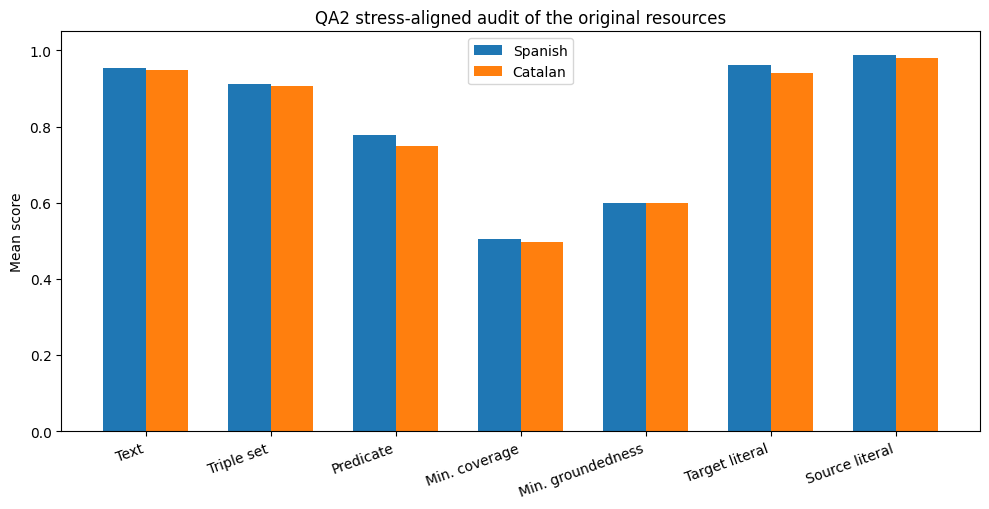

Saved QA2 outputs to /home/vramon/notebooks/WebNLG_MT_eval/QA_evaluation/results/QA2_stress_aligned


In [8]:
metric_columns = [
    "text_similarity",
    "triple_similarity",
    "predicate_similarity",
    "minimum_triple_coverage",
    "minimum_text_groundedness",
    "target_text_literal_retention",
    "source_target_literal_preservation",
]

figure_data = (
    metrics.melt(
        id_vars=["language_label"],
        value_vars=metric_columns,
        var_name="metric",
        value_name="score",
    )
    .dropna()
)

fig, ax = plt.subplots(figsize=(10, 5.2))
positions = np.arange(len(metric_columns))
width = 0.34
for offset, language in zip(
    [-width / 2, width / 2],
    ["Spanish", "Catalan"],
):
    values = (
        figure_data[
            figure_data["language_label"].eq(language)
        ]
        .groupby("metric")["score"]
        .mean()
        .reindex(metric_columns)
    )
    ax.bar(
        positions + offset,
        values,
        width=width,
        label=language,
    )
ax.set_xticks(
    positions,
    [
        "Text",
        "Triple set",
        "Predicate",
        "Min. coverage",
        "Min. groundedness",
        "Target literal",
        "Source literal",
    ],
    rotation=20,
    ha="right",
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean score")
ax.set_title("QA2 stress-aligned audit of the original resources")
ax.legend()
fig.tight_layout()
fig.savefig(
    RESULTS_DIR / "qa2_stress_aligned_summary.pdf",
    bbox_inches="tight",
)
fig.savefig(
    RESULTS_DIR / "qa2_stress_aligned_summary.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

metrics.to_pickle(
    RESULTS_DIR / "qa2_lexicalisation_metrics.pkl"
)
metrics.to_csv(
    RESULTS_DIR / "qa2_lexicalisation_metrics.csv",
    index=False,
)
summary.to_csv(
    RESULTS_DIR / "qa2_original_summary.csv",
    index=False,
)
qa22_thresholds.to_csv(
    RESULTS_DIR / "qa22_english_calibration_thresholds.csv",
    index=False,
)
relative_literal_summary.to_csv(
    RESULTS_DIR / "qa22_relative_literal_retention.csv",
    index=False,
)
paired_bootstrap.to_csv(
    RESULTS_DIR
    / "qa2_spanish_catalan_cluster_bootstrap.csv",
    index=False,
)

manual_groups = []
for language, group in metrics.groupby(
    "language",
    sort=True,
):
    manual_groups.append(
        group.sample(
            min(60, len(group)),
            random_state=RANDOM_SEED,
        )
    )
manual = pd.concat(
    manual_groups,
    ignore_index=True,
)
manual["manual_target_triples_correct"] = ""
manual["manual_text_adequacy_1_5"] = ""
manual["manual_all_facts_expressed"] = ""
manual["manual_unsupported_addition"] = ""
manual["manual_entities_values_correct"] = ""
manual["manual_notes"] = ""
manual.to_csv(
    RESULTS_DIR / "manual_qa2_audit_sheet.csv",
    index=False,
)

metadata = {
    "metric_core_compatibility": core.CORE_COMPATIBILITY,
    "metric_core_sha256": CORE_SHA256,
    "semantic_backend": SEMANTIC_BACKEND,
    "semantic_model": SEMANTIC_MODEL,
    "batch_size": BATCH_SIZE,
    "bootstrap_replicates": BOOTSTRAP_REPLICATES,
    "source_rdf": "modifiedtripleset/mtriple",
    "qa21_evaluation_unit": (
        "aligned RDF-to-text instance: RDF entry, lexicalisation ID, "
        "and target language"
    ),
    "qa21_shared_metric_core": True,
    "qa21_similarity_definition": (
        "cosine similarity of L2-normalised multilingual sentence "
        "embeddings"
    ),
    "qa21_triple_serialization": (
        "complete ordered triple set with explicit [S], [P], and [O] markers"
    ),
    "qa21_predicate_alignment": (
        "all predicates aligned by triple position; unequal counts or empty "
        "predicates yield undefined PredSim"
    ),
    "qa21_structured_predicate_rule": (
        "camelCase English predicate unchanged after shared N normalisation"
    ),
    "qa21_literal_atom_scope": (
        "subject, predicate, and object components of the complete triple set"
    ),
    "qa22_evaluation_unit": (
        "aligned RDF-to-text instance: RDF entry, lexicalisation ID, "
        "and target language"
    ),
    "qa22_shared_metric_core": True,
    "qa22_textual_units": (
        "sentence-level units from audit_metric_core.textual_units"
    ),
    "qa22_literal_atom_scope": (
        "subject, predicate, and object components of complete triple sets"
    ),
    "qa22_calibration_stratification": (
        "exact actual triple-set size; no global fallback"
    ),
    "coverage_calibration_percentile": ENGLISH_SUPPORT_PERCENTILE,
    "groundedness_calibration_percentile": ENGLISH_SUPPORT_PERCENTILE,
    "qa22_english_calibration_instances": int(len(english_calibration)),
    "qa22_relative_literal_denominator_rule": (
        "English triples contain atoms and all are realised in English gold"
    ),
    "qa21_instances": int(len(metrics)),
    "lexicalisations": int(len(metrics)),
}
(
    RESULTS_DIR / "qa2_run_metadata.json"
).write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

print("Saved QA2 outputs to", RESULTS_DIR)
